<div style="
  background-color:#CD5C5C;
  padding:20px;
  border-radius:12px;
  text-align:center;
  color:white;
  margin-bottom:20px;
">

  <h1 style="margin:0;">
    Baseline models — Prédiction du prix immobilier
  </h1>

  <p style="margin:5px 0 0 0; font-size:16px;">
    Notebook 02 : Construction et Comparaison des Modèles de Scoring
  </p>

</div>

### Objectifs de ce Notebook

**ÉTAPE 1 : Préparation des Données**

* 1.1 — Chargement des Données Préparées et séparation des données
* 1.2 — Identification des Variables par Type
* 1.3 — Construction du Pipeline de Préprocessing
* 1.4 — Gestion des Outliers (Winsorization + Transformation log)

**ÉTAPE 2 : Modèle Baseline — Régression Linéaire**

* 2.1 — Entraînement du Modèle
* 2.2 — Évaluation des Performances

**ÉTAPE 3 : XGBoost (Modèle Boosting)**

* 3.1 — Entraînement et Évaluation du Modèle
* 3.2 — Importance des Variables

**ÉTAPE 4 : Random Forest (Modèle Bagging)**

* 4.1 — Entraînement et Évaluation du Modèle
* 4.2 — Importance des Variables

**ÉTAPE 5 : Synthèse et Comparaison des Modèles**

* 5.1 — Tableau Comparatif des Performances
* 5.2 — Analyse des Erreurs et des Résidus
* 5.3 — Interprétation des Résultats

**ÉTAPE 6 : Sauvegarde des Modèles Baseline**

* 6.1 — Export des Pipelines

**Synthèse Générale du Notebook 02**

In [ ]:
"""
Configuration de l'environnement — Prédiction du prix immobilier
===================================================
Imports et configuration pour la modélisation baseline (régression).
"""

import os
import psutil
import sys
import multiprocessing

# Nombre de cœurs disponibles
num_cores = multiprocessing.cpu_count()
print(f"Nombre de cœurs disponibles : {num_cores}")

# Nombre total de coeurs physiques
num_physical_cores = psutil.cpu_count(logical=True)

# Laisser un cœur libre pour le système
num_cores_to_use = max(1, num_physical_cores - 1)

# Manipulation de données
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de régression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Prétraitement et pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métriques de régression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Répertoire de sauvegarde des figures
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports', 'figures'))
os.makedirs(FIGURES_DIR, exist_ok=True)

# Seed pour la reproductibilité
RANDOM_STATE = 1204

print(" Imports chargés avec succès")

Nombre de cœurs disponibles : 16
 Imports chargés avec succès


---

## ÉTAPE 1 : Préparation des Données

### 1.1 — Chargement des Données et Séparation Train / Test

In [2]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\nyc-rolling-sales.csv")
print(f" Dataset importé : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

# ============================================================
# Séparation features / cible
# ============================================================
Target = "SALE PRICE"

# Conversion de la cible en numérique (valeurs comme " - " → NaN)
df[Target] = pd.to_numeric(df[Target], errors="coerce")

X = df.drop(columns=[Target])
y = df[Target]

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Limitation du jeu d'entraînement à 10 000 lignes max ---
MAX_TRAIN = 10_000
if len(X_train) > MAX_TRAIN:
    X_train = X_train.sample(n=MAX_TRAIN, random_state=RANDOM_STATE)
    y_train = y_train.loc[X_train.index]

# --- Affichage des dimensions ---
print("\n" + "=" * 70)
print("  DIMENSIONS DES DONNÉES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible         (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible         (y_test)  : {y_test.shape}")
print("=" * 70)

 Dataset importé : 84548 lignes et 22 colonnes


  DIMENSIONS DES DONNÉES
  Variables explicatives (X_train) : (10000, 21)
  Variable cible         (y_train) : (10000,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (16910, 21)
  Variable cible         (y_test)  : (16910,)


### 1.2 — Identification des Variables par Type

In [3]:
# Identification des types de variables sur le jeu d'entraînement
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f" {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f" {len(num_cols)} variables numériques    : {num_cols}\n")
print(f" Total : {len(cat_cols) + len(num_cols)} variables")

 11 variables catégorielles : ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING CLASS AT TIME OF SALE', 'SALE DATE']

 10 variables numériques    : ['Unnamed: 0', 'BOROUGH', 'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE']

 Total : 21 variables


### 1.3 — Construction du Pipeline de Préprocessing

Nettoyage des données (suppression des prix invalides) + transformation log de la cible + construction du pipeline de prétraitement.

In [4]:
# ============================================================
# Nettoyage : suppression des prix invalides (NaN ou ≤ 0)
# ============================================================
mask_train = y_train.notna() & (y_train > 0)
mask_test = y_test.notna() & (y_test > 0)

X_train_clean = X_train[mask_train].reset_index(drop=True)
y_train_clean = y_train[mask_train].reset_index(drop=True)
X_test_clean = X_test[mask_test].reset_index(drop=True)
y_test_clean = y_test[mask_test].reset_index(drop=True)

print(f" Entraînement : {len(X_train_clean)} lignes conservées / {len(X_train)} ({len(X_train_clean)/len(X_train)*100:.1f}%)")
print(f" Test         : {len(X_test_clean)} lignes conservées / {len(X_test)} ({len(X_test_clean)/len(X_test)*100:.1f}%)")

# ============================================================
# Transformation log de la cible (recommandée par l'analyse exploratoire)
# ============================================================
y_train_log = np.log1p(y_train_clean)
y_test_log = np.log1p(y_test_clean)

print(f"\n Transformation log1p appliquée à SALE PRICE")
print(f"   Moyenne y_train (log) : {y_train_log.mean():.2f}")
print(f"   Écart-type y_train (log) : {y_train_log.std():.2f}")

# ============================================================
# Analyse de la cardinalité des variables catégorielles
# ============================================================
print(f"\n Cardinalité des variables catégorielles :")
for col in cat_cols:
    n_unique = X_train_clean[col].nunique()
    print(f"   {col:<25s} : {n_unique} modalités")

# ============================================================
# Pipeline de préprocessing
# ============================================================

# Transformer pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer pour les variables catégorielles
# max_categories=30 pour limiter la dimensionnalité (les modalités rares
# sont regroupées dans une catégorie "infrequent" automatiquement)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        max_categories=30
    ))
])

# ColumnTransformer : combine les deux transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

print(f"\n Pipeline de préprocessing construit :")
print(f"   Numériques    : {len(num_cols)} colonnes → Imputation médiane + StandardScaler")
print(f"   Catégorielles : {len(cat_cols)} colonnes → Imputation mode + OneHotEncoder (max 30 catégories/variable)")

 Entraînement : 7110 lignes conservées / 10000 (71.1%)
 Test         : 12007 lignes conservées / 16910 (71.0%)

 Transformation log1p appliquée à SALE PRICE
   Moyenne y_train (log) : 13.26
   Écart-type y_train (log) : 1.67

 Cardinalité des variables catégorielles :
   NEIGHBORHOOD              : 244 modalités
   BUILDING CLASS CATEGORY   : 39 modalités
   TAX CLASS AT PRESENT      : 10 modalités
   EASE-MENT                 : 1 modalités
   BUILDING CLASS AT PRESENT : 106 modalités
   ADDRESS                   : 6551 modalités
   APARTMENT NUMBER          : 731 modalités
   LAND SQUARE FEET          : 1353 modalités
   GROSS SQUARE FEET         : 1497 modalités
   BUILDING CLASS AT TIME OF SALE : 104 modalités
   SALE DATE                 : 280 modalités

 Pipeline de préprocessing construit :
   Numériques    : 10 colonnes → Imputation médiane + StandardScaler
   Catégorielles : 11 colonnes → Imputation mode + OneHotEncoder (max 30 catégories/variable)


**Analyse — Nettoyage et pipeline de preprocessing**

Le nettoyage élimine les transactions à prix NaN ou ≤ 0, conservant **71 % des données** (7 110 / 10 000 en train). La perte de 29 % s'explique par les 17 % de NaN sur `SALE PRICE` + les 1 154 transactions à $0 identifiées dans le Notebook 01.

La transformation `log1p` produit une moyenne de 13,26 et un écart-type de 1,67 en échelle log — la distribution est bien plus compacte. Cependant, la **cardinalité très élevée** de certaines catégorielles pose un défi :
- `ADDRESS` (6 551 modalités) et `GROSS SQUARE FEET` (1 497 modalités en texte) créeront une explosion dimensionnelle après OneHotEncoding.
- Le paramètre `max_categories=30` limite ce risque en regroupant les modalités rares dans une catégorie `infrequent`.

> **Transition →** Avant d'entraîner les modèles, il faut traiter les outliers de la cible (valeurs extrêmes identifiées : min $1, max $268M) via une winsorization pour stabiliser l'apprentissage.

### 1.4 — Gestion des Outliers (Winsorization + Transformation log)

Les biens de luxe créent des outliers naturels. Trois stratégies identifiées lors de l'exploration :
- **Option A** : Cap les prix extrêmes (winsorization) — appliquée ici
- **Option B** : Modéliser sur log(prix) — déjà appliqué via `log1p`
- **Option C** : Segmenter luxe vs standard — à explorer en Notebook 03

  GESTION DES OUTLIERS — SALE PRICE

  Avant winsorization :
    Min          : $1
    Max          : $268,124,175
    Percentile 1%  : $10
    Percentile 99% : $12,895,500

  Après winsorization (clip P1-P99) :
    Min (train)  : $10
    Max (train)  : $12,895,500
    Min (test)   : $10
    Max (test)   : $12,895,500

  Transformation log1p recalculée après winsorization :
    Moyenne y_train (log) : 13.25
    Écart-type (log)      : 1.63
    Skewness (log)        : -3.74


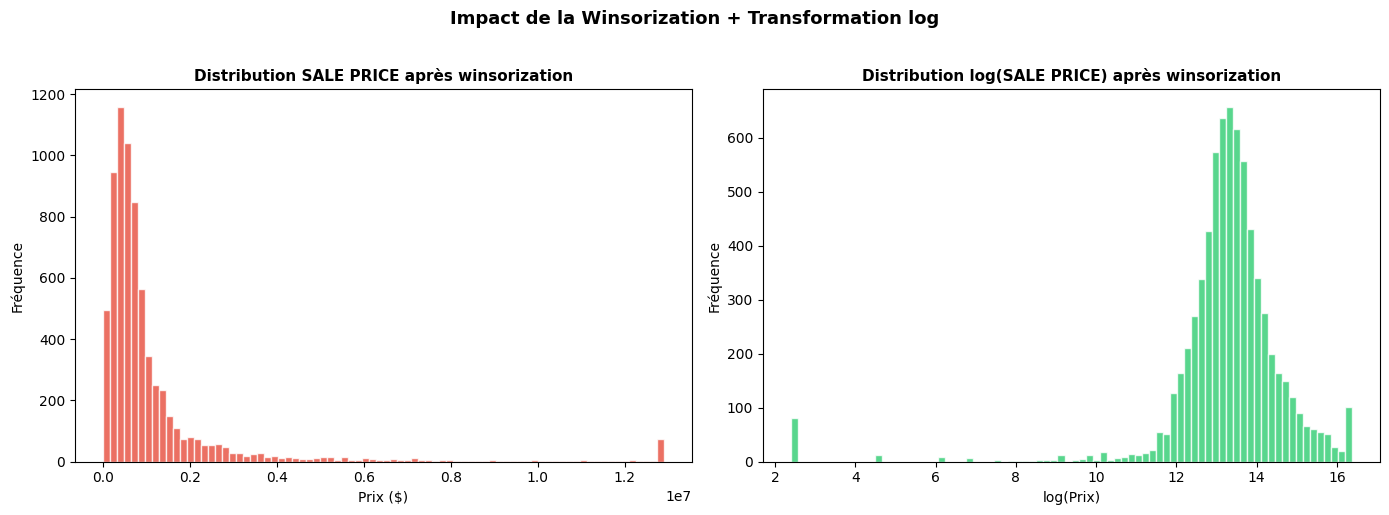

In [5]:
# ============================================================
# Gestion des Outliers — Winsorization de la variable cible
# ============================================================
print("=" * 70)
print("  GESTION DES OUTLIERS — SALE PRICE")
print("=" * 70)

# --- Statistiques avant traitement ---
Q1 = y_train_clean.quantile(0.01)
Q99 = y_train_clean.quantile(0.99)
print(f"\n  Avant winsorization :")
print(f"    Min          : ${y_train_clean.min():,.0f}")
print(f"    Max          : ${y_train_clean.max():,.0f}")
print(f"    Percentile 1%  : ${Q1:,.0f}")
print(f"    Percentile 99% : ${Q99:,.0f}")

# --- Option A : Winsorization (cap au 1er et 99ème percentile) ---
y_train_clean = y_train_clean.clip(lower=Q1, upper=Q99)

# Appliquer les mêmes bornes au test (pas de data leakage)
y_test_clean = y_test_clean.clip(lower=Q1, upper=Q99)

print(f"\n  Après winsorization (clip P1-P99) :")
print(f"    Min (train)  : ${y_train_clean.min():,.0f}")
print(f"    Max (train)  : ${y_train_clean.max():,.0f}")
print(f"    Min (test)   : ${y_test_clean.min():,.0f}")
print(f"    Max (test)   : ${y_test_clean.max():,.0f}")

# --- Option B : Recalcul de la transformation log après winsorization ---
y_train_log = np.log1p(y_train_clean)
y_test_log = np.log1p(y_test_clean)

print(f"\n  Transformation log1p recalculée après winsorization :")
print(f"    Moyenne y_train (log) : {y_train_log.mean():.2f}")
print(f"    Écart-type (log)      : {y_train_log.std():.2f}")
print(f"    Skewness (log)        : {y_train_log.skew():.2f}")

# --- Visualisation avant/après ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train_clean, bins=80, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribution SALE PRICE après winsorization", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Prix ($)")
axes[0].set_ylabel("Fréquence")

axes[1].hist(y_train_log, bins=80, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribution log(SALE PRICE) après winsorization", fontsize=11, fontweight="bold")
axes[1].set_xlabel("log(Prix)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Impact de la Winsorization + Transformation log", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "02_Impact de la Winsorization + Transformation log.png"), dpi=300)

plt.show()

print("\n" + "=" * 70)

**Analyse — Impact de la winsorization**

La winsorization au P1–P99 ramène la plage de prix de [$1 — $268M] à [$10 — $12,9M]. Après recalcul de `log1p`, le skewness passe à **-3,74** (devenu asymétrique à gauche) — cela indique que les transactions à bas prix ($10–$100) tirent maintenant la distribution vers la gauche.

La visualisation avant/après montre :
- **Distribution brute** : encore très étalée vers la droite malgré la winsorization.
- **Distribution log** : plus concentrée, mais le skewness négatif suggère une accumulation de biens à très bas prix (< $1 000), qui sont probablement des transferts déguisés.

> **Point d'attention** : Le seuil P1 = $10 est très bas. Le Notebook 03 filtrera plus agressivement en excluant les prix ≤ $1 000.

> **Transition →** Le preprocessing est en place. On entraîne le premier modèle baseline : une régression linéaire simple, pour établir le plancher de performance.

---

## ÉTAPE 2 : Modèle Baseline — Régression Linéaire

### 2.1 — Entraînement du Modèle

In [6]:
# ============================================================
# Construction du pipeline : Préprocessing + Régression Linéaire
# ============================================================
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entraînement
pipe_lr.fit(X_train_clean, y_train_log)

# Prédictions (échelle log)
y_pred_train_lr = pipe_lr.predict(X_train_clean)
y_pred_test_lr = pipe_lr.predict(X_test_clean)

print(" Modèle de Régression Linéaire entraîné avec succès")
print(f"   Nombre de coefficients : {len(pipe_lr.named_steps['regressor'].coef_)}")

 Modèle de Régression Linéaire entraîné avec succès
   Nombre de coefficients : 291


### 2.2 — Évaluation des Performances

In [7]:
# ============================================================
# Fonction d'évaluation pour les modèles de régression
# ============================================================
def evaluate_regression(y_true_log, y_pred_log, y_true_orig, label=""):
    """Calcule et affiche les métriques de régression (RMSE, MAE, R², MAPE)."""
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)

    # MAPE sur l'échelle originale
    y_pred_orig = np.expm1(y_pred_log)
    mask = y_true_orig > 0
    mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask]) / y_true_orig[mask])) * 100

    print(f"\n  {label}")
    print(f"  {'─' * 40}")
    print(f"  RMSE (log)  : {rmse:.4f}")
    print(f"  MAE  (log)  : {mae:.4f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  MAPE (%)    : {mape:.2f}%")

    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

# ============================================================
# Évaluation — Régression Linéaire
# ============================================================
print("=" * 60)
print("  RÉGRESSION LINÉAIRE — ÉVALUATION")
print("=" * 60)

metrics_lr_train = evaluate_regression(y_train_log, y_pred_train_lr, y_train_clean, "Train")
metrics_lr_test = evaluate_regression(y_test_log, y_pred_test_lr, y_test_clean, "Test")

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(pipe_lr, X_train_clean, y_train_log, cv=cv, scoring='r2')
print(f"\n  Cross-Validation R² (5 folds) : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

  RÉGRESSION LINÉAIRE — ÉVALUATION

  Train
  ────────────────────────────────────────
  RMSE (log)  : 1.4350
  MAE  (log)  : 0.7140
  R²          : 0.2219
  MAPE (%)    : 60803.53%

  Test
  ────────────────────────────────────────
  RMSE (log)  : 1.7076
  MAE  (log)  : 0.7922
  R²          : 0.0772
  MAPE (%)    : 165490.53%

  Cross-Validation R² (5 folds) : 0.1021 ± 0.0456


**Analyse — Régression Linéaire (baseline)**

Les résultats sont décevants mais attendus :
- **R² train = 0,22** / **R² test = 0,08** : le modèle n'explique que 8 % de la variance du prix sur le test. Les 291 coefficients (issus du OneHotEncoding) ne suffisent pas à capturer les relations complexes.
- **MAPE > 60 000 %** : cette métrique explose car les transactions à très bas prix ($10–$100) génèrent des erreurs relatives astronomiques.
- **CV R² = 0,10 ± 0,05** : la cross-validation confirme des performances faibles mais stables (pas d'overfitting).

Le modèle linéaire échoue car les relations prix/features sont **non linéaires** (comme pressenti dans le Notebook 01 par les faibles corrélations). C'est notre plancher de référence.

> **Transition →** On passe aux modèles d'ensemble (XGBoost, Random Forest) capables de capturer des interactions non linéaires et des seuils dans les variables.

---

## ÉTAPE 3 : XGBoost (Modèle Boosting)

### 3.1 — Entraînement et Évaluation du Modèle

In [8]:
# ============================================================
# Construction du pipeline : Préprocessing + XGBoost
# ============================================================
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Entraînement
pipe_xgb.fit(X_train_clean, y_train_log)

# Prédictions
y_pred_train_xgb = pipe_xgb.predict(X_train_clean)
y_pred_test_xgb = pipe_xgb.predict(X_test_clean)

# Évaluation
print("=" * 60)
print("  XGBOOST — ÉVALUATION")
print("=" * 60)

metrics_xgb_train = evaluate_regression(y_train_log, y_pred_train_xgb, y_train_clean, "Train")
metrics_xgb_test = evaluate_regression(y_test_log, y_pred_test_xgb, y_test_clean, "Test")

# Cross-validation
cv_scores_xgb = cross_val_score(pipe_xgb, X_train_clean, y_train_log, cv=cv, scoring='r2')
print(f"\n  Cross-Validation R² (5 folds) : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

  XGBOOST — ÉVALUATION

  Train
  ────────────────────────────────────────
  RMSE (log)  : 0.9761
  MAE  (log)  : 0.4881
  R²          : 0.6400
  MAPE (%)    : 8064.62%

  Test
  ────────────────────────────────────────
  RMSE (log)  : 1.7915
  MAE  (log)  : 0.9819
  R²          : -0.0158
  MAPE (%)    : 115828.20%

  Cross-Validation R² (5 folds) : 0.0917 ± 0.0172


### 3.2 — Importance des Variables (XGBoost)

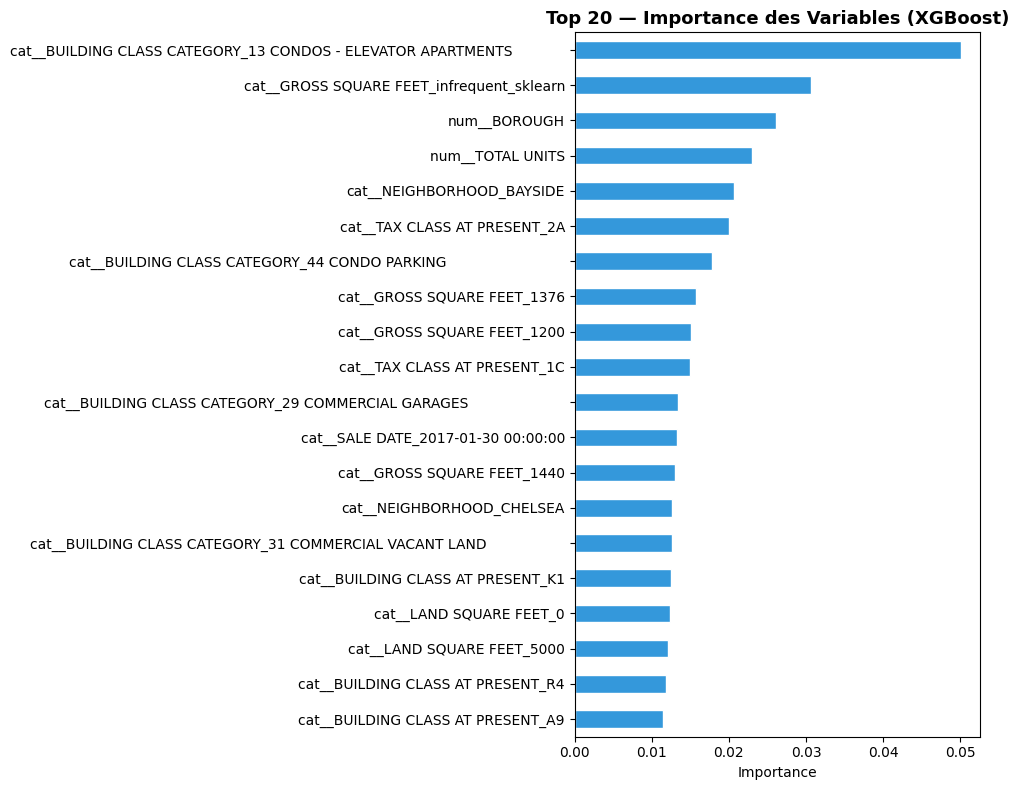


 Top 5 variables les plus importantes (XGBoost) :
   1. cat__BUILDING CLASS CATEGORY_13 CONDOS - ELEVATOR APARTMENTS             : 0.0501
   2. cat__GROSS SQUARE FEET_infrequent_sklearn : 0.0306
   3. num__BOROUGH : 0.0261
   4. num__TOTAL UNITS : 0.0230
   5. cat__NEIGHBORHOOD_BAYSIDE : 0.0207


In [9]:
# ============================================================
# Importance des Variables — XGBoost
# ============================================================
xgb_model = pipe_xgb.named_steps['regressor']
feature_names = pipe_xgb.named_steps['preprocessor'].get_feature_names_out()

importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names)
top_features_xgb = importances_xgb.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_features_xgb.sort_values().plot(kind='barh', color='#3498db', edgecolor='white', ax=ax)
ax.set_title("Top 20 — Importance des Variables (XGBoost)", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance")
plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "02_Top 20 Importance des Variables (XGBoost).png"), dpi=300)

plt.show()

print(f"\n Top 5 variables les plus importantes (XGBoost) :")
for i, (feat, imp) in enumerate(top_features_xgb.head(5).items(), 1):
    print(f"   {i}. {feat} : {imp:.4f}")

**Analyse — XGBoost baseline**

XGBoost montre un **fort overfitting** :
- **R² train = 0,64** vs **R² test = -0,02** : le modèle apprend le bruit du train et ne généralise pas du tout. Un R² négatif sur le test signifie qu'il fait pire que la simple moyenne.
- Le **CV R² = 0,09** confirme que la performance réelle est très faible.
- L'importance des variables montre que le modèle s'appuie sur `BUILDING CLASS CATEGORY_13 CONDOS` (5 %) et `GROSS SQUARE FEET_infrequent` (3 %) — des features à forte cardinalité qui permettent de « mémoriser » des cas particuliers du train.

Le problème principal : les hyperparamètres par défaut (`max_depth=6`, `n_estimators=200`) sont trop expressifs pour un dataset bruité. Le modèle a besoin de **régularisation** (profondeur réduite, learning rate plus bas, subsampling).

> **Transition →** Voyons si le Random Forest, moins sujet à l'overfitting grâce au bagging, obtient de meilleurs résultats en test.

---

## ÉTAPE 4 : Random Forest (Modèle Bagging)

### 4.1 — Entraînement et Évaluation du Modèle

In [10]:
# ============================================================
# Construction du pipeline : Préprocessing + Random Forest
# ============================================================
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Entraînement
pipe_rf.fit(X_train_clean, y_train_log)

# Prédictions
y_pred_train_rf = pipe_rf.predict(X_train_clean)
y_pred_test_rf = pipe_rf.predict(X_test_clean)

# Évaluation
print("=" * 60)
print("  RANDOM FOREST — ÉVALUATION")
print("=" * 60)

metrics_rf_train = evaluate_regression(y_train_log, y_pred_train_rf, y_train_clean, "Train")
metrics_rf_test = evaluate_regression(y_test_log, y_pred_test_rf, y_test_clean, "Test")

# Cross-validation
cv_scores_rf = cross_val_score(pipe_rf, X_train_clean, y_train_log, cv=cv, scoring='r2')
print(f"\n  Cross-Validation R² (5 folds) : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

  RANDOM FOREST — ÉVALUATION

  Train
  ────────────────────────────────────────
  RMSE (log)  : 0.9256
  MAE  (log)  : 0.4539
  R²          : 0.6763
  MAPE (%)    : 3898.49%

  Test
  ────────────────────────────────────────
  RMSE (log)  : 1.6673
  MAE  (log)  : 0.7171
  R²          : 0.1202
  MAPE (%)    : 137231.03%

  Cross-Validation R² (5 folds) : 0.1806 ± 0.0408


### 4.2 — Importance des Variables (Random Forest)

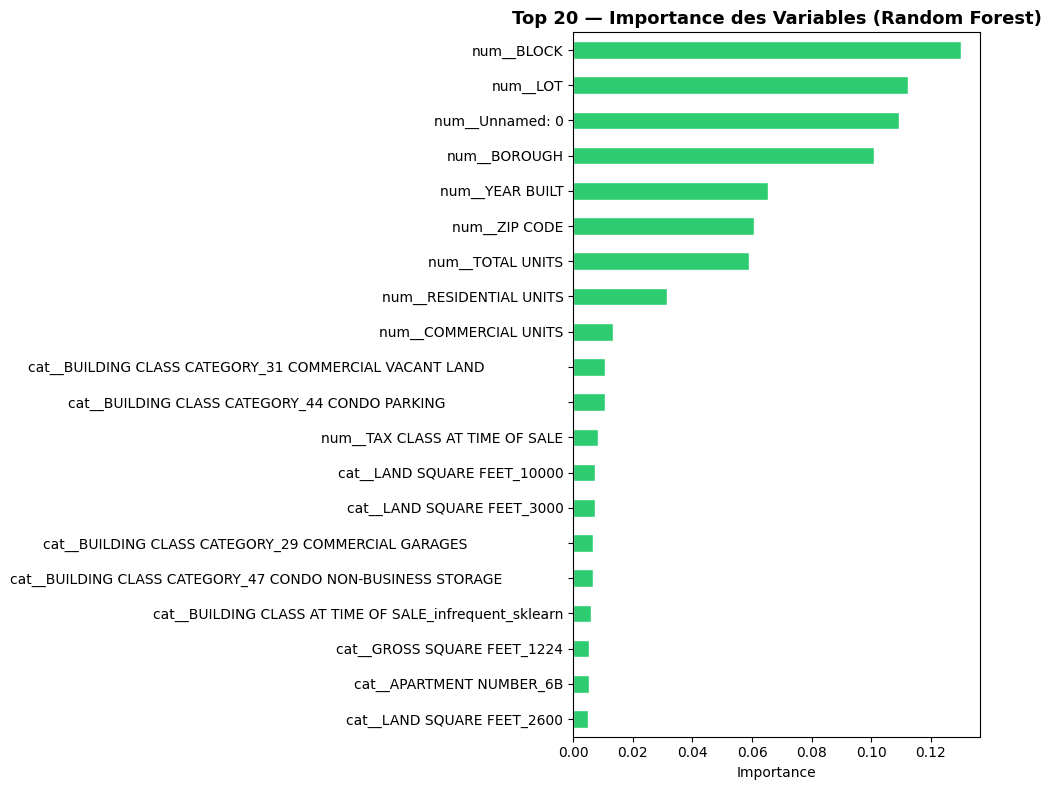


 Top 5 variables les plus importantes (Random Forest) :
   1. num__BLOCK : 0.1299
   2. num__LOT : 0.1122
   3. num__Unnamed: 0 : 0.1093
   4. num__BOROUGH : 0.1009
   5. num__YEAR BUILT : 0.0652


In [11]:
# ============================================================
# Importance des Variables — Random Forest
# ============================================================
rf_model = pipe_rf.named_steps['regressor']
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_names)
top_features_rf = importances_rf.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top_features_rf.sort_values().plot(kind='barh', color='#2ecc71', edgecolor='white', ax=ax)
ax.set_title("Top 20 — Importance des Variables (Random Forest)", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance")
plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "02_Top 20 Importance des Variables (Random Forest).png"), dpi=300)

plt.show()

print(f"\n Top 5 variables les plus importantes (Random Forest) :")
for i, (feat, imp) in enumerate(top_features_rf.head(5).items(), 1):
    print(f"   {i}. {feat} : {imp:.4f}")

**Analyse — Random Forest baseline**

Le Random Forest est le **meilleur modèle baseline** avec R² test = 0,12 et CV R² = 0,18 :
- L'overfitting est nettement moindre que XGBoost (R² train = 0,68 vs test = 0,12) — le bagging réduit la variance.
- Les **variables les plus importantes** sont structurelles : `BLOCK` (13 %), `LOT` (11 %), `BOROUGH` (10 %), `YEAR BUILT` (6,5 %). Contrairement à XGBoost, le RF utilise des features géographiques et physiques plutôt que des modalités catégorielles spécifiques.
- Le fait que `Unnamed: 0` apparaisse dans le top 3 (11 %) est un signal que le modèle utilise cette variable comme proxy (elle est corrélée à l'ordre d'insertion, donc potentiellement à la géographie).

Néanmoins, R² = 0,12 reste faible : le modèle n'explique que 12 % de la variance du prix.

> **Transition →** Comparons les trois modèles, analysons les résidus et identifions les pistes d'amélioration pour le Notebook 03.

---

## ÉTAPE 5 : Synthèse et Comparaison des Modèles

### 5.1 — Tableau Comparatif des Performances

In [12]:
# ============================================================
# Tableau Comparatif des Performances
# ============================================================
comparison = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'XGBoost', 'Random Forest'],
    'RMSE (test)': [metrics_lr_test['RMSE'], metrics_xgb_test['RMSE'], metrics_rf_test['RMSE']],
    'MAE (test)': [metrics_lr_test['MAE'], metrics_xgb_test['MAE'], metrics_rf_test['MAE']],
    'R² (test)': [metrics_lr_test['R²'], metrics_xgb_test['R²'], metrics_rf_test['R²']],
    'MAPE (test)': [metrics_lr_test['MAPE'], metrics_xgb_test['MAPE'], metrics_rf_test['MAPE']],
    'CV R² (mean)': [cv_scores_lr.mean(), cv_scores_xgb.mean(), cv_scores_rf.mean()],
    'CV R² (std)': [cv_scores_lr.std(), cv_scores_xgb.std(), cv_scores_rf.std()]
})

print("=" * 80)
print("  COMPARAISON DES MODÈLES BASELINE")
print("=" * 80 + "\n")

display(
    comparison.style
    .highlight_min(
        subset=['RMSE (test)', 'MAE (test)', 'MAPE (test)'],
        color='#2e7d32'
    )
    .highlight_max(
        subset=['R² (test)', 'CV R² (mean)'],
        color='#2e7d32'
    )
    .format({
        'RMSE (test)': '{:.4f}',
        'MAE (test)': '{:.4f}',
        'R² (test)': '{:.4f}',
        'MAPE (test)': '{:.2f}%',
        'CV R² (mean)': '{:.4f}',
        'CV R² (std)': '{:.4f}'
    })
)

  COMPARAISON DES MODÈLES BASELINE



,Modèle,RMSE (test),MAE (test),R² (test),MAPE (test),CV R² (mean),CV R² (std)
0,Régression Linéaire,1.7076,0.7922,0.0772,165490.53%,0.1021,0.0456
1,XGBoost,1.7915,0.9819,-0.0158,115828.20%,0.0917,0.0172
2,Random Forest,1.6673,0.7171,0.1202,137231.03%,0.1806,0.0408


### 5.2 — Analyse des Erreurs et des Résidus

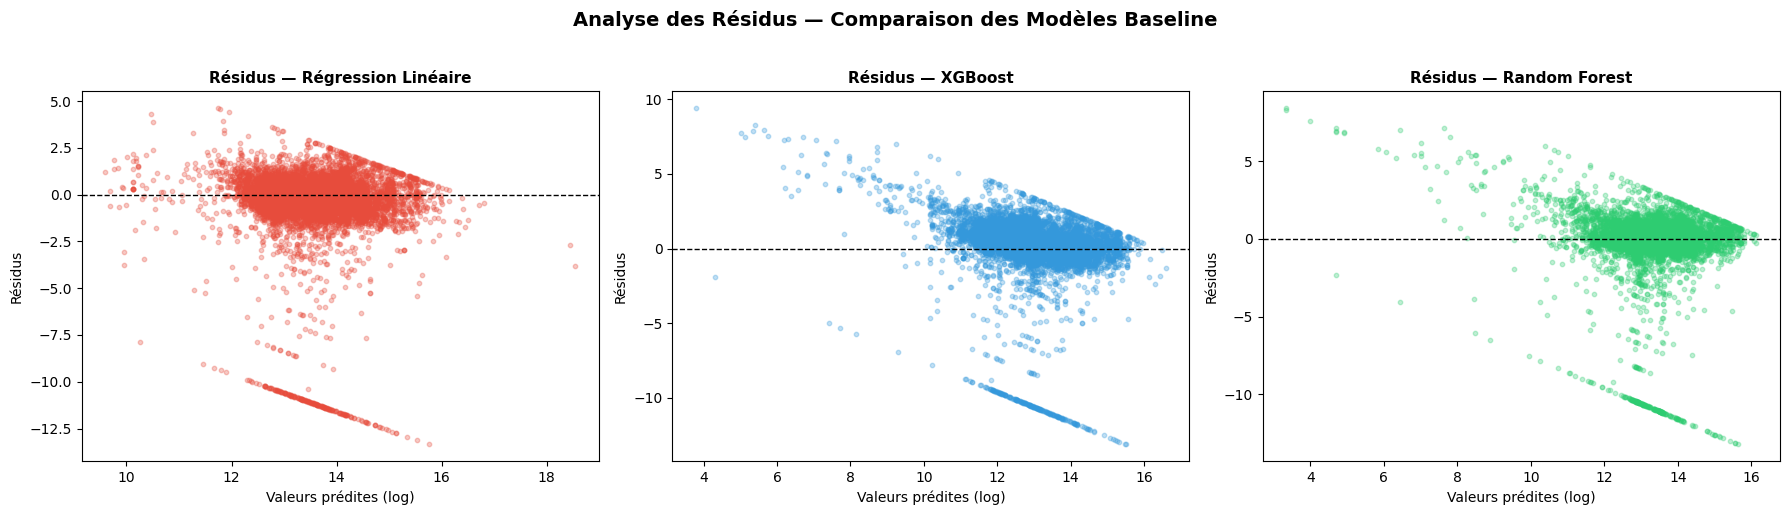

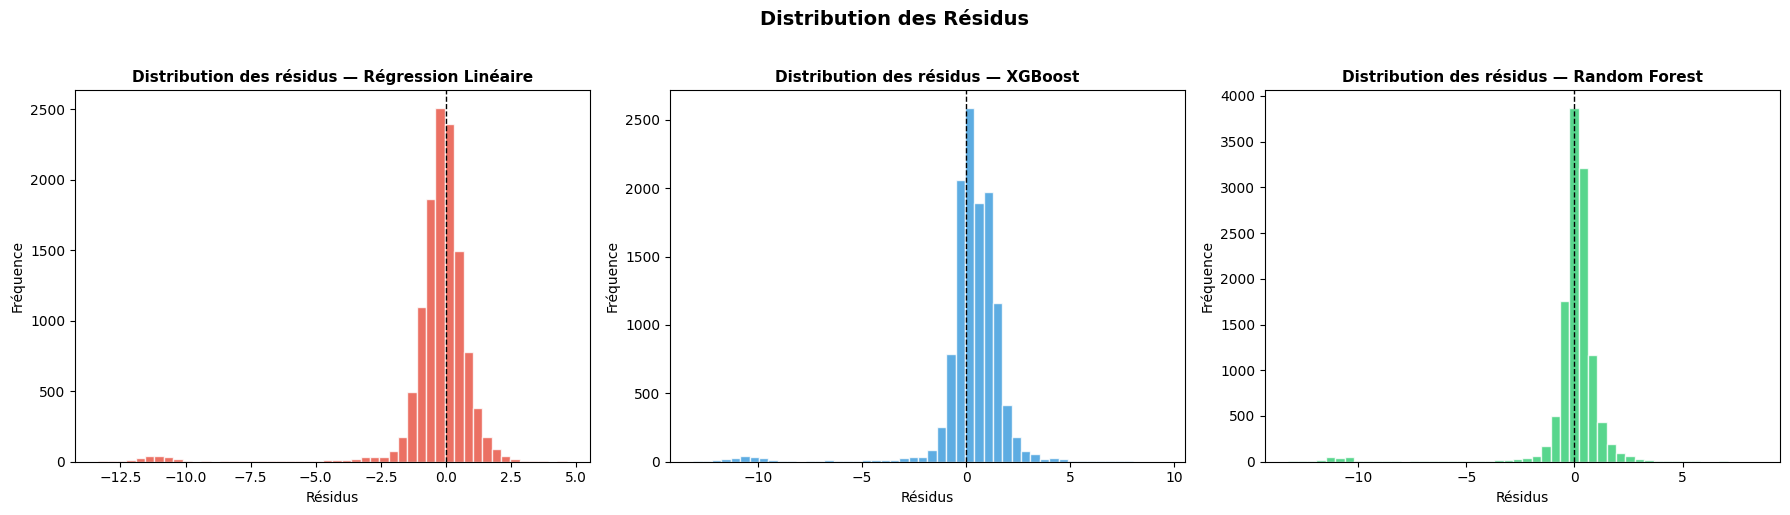

In [13]:
# ============================================================
# Analyse des Résidus — Comparaison des 3 modèles
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ("Régression Linéaire", y_pred_test_lr, "#e74c3c"),
    ("XGBoost", y_pred_test_xgb, "#3498db"),
    ("Random Forest", y_pred_test_rf, "#2ecc71"),
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    residuals = y_test_log.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"Résidus — {name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Valeurs prédites (log)")
    ax.set_ylabel("Résidus")

plt.suptitle("Analyse des Résidus — Comparaison des Modèles Baseline",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Distribution des résidus
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, color) in zip(axes, models_info):
    residuals = y_test_log.values - y_pred
    ax.hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"Distribution des résidus — {name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Résidus")
    ax.set_ylabel("Fréquence")

plt.suptitle("Distribution des Résidus", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "02_Distribution des Résidus.png"), dpi=300)

plt.show()

### 5.3 — Interprétation des Résultats

In [14]:
# ============================================================
# Interprétation des Résultats
# ============================================================
print("=" * 70)
print("  INTERPRÉTATION DES RÉSULTATS")
print("=" * 70)

# Identifier le meilleur modèle
best_idx = comparison['R² (test)'].idxmax()
best_model_name = comparison.loc[best_idx, 'Modèle']
best_r2 = comparison.loc[best_idx, 'R² (test)']
best_rmse = comparison.loc[best_idx, 'RMSE (test)']
best_mape = comparison.loc[best_idx, 'MAPE (test)']

print(f"\n Meilleur modèle baseline : {best_model_name}")
print(f"   R² (test)   : {best_r2:.4f}")
print(f"   RMSE (test) : {best_rmse:.4f}")
print(f"   MAPE (test) : {best_mape:.2f}%")

# Vérification overfitting
print(f"\n Diagnostic d'overfitting :")
for _, row in comparison.iterrows():
    name = row['Modèle']
    r2_mean = row['CV R² (mean)']
    r2_std = row['CV R² (std)']
    r2_test = row['R² (test)']
    gap = abs(r2_test - r2_mean)
    status = "Possible overfitting" if gap > 0.1 else "Stable"
    print(f"\n  {name} :")
    print(f"    R² test = {r2_test:.4f} | CV R² = {r2_mean:.4f} ± {r2_std:.4f} | {status}")

print("\n" + "=" * 70)

  INTERPRÉTATION DES RÉSULTATS

 Meilleur modèle baseline : Random Forest
   R² (test)   : 0.1202
   RMSE (test) : 1.6673
   MAPE (test) : 137231.03%

 Diagnostic d'overfitting :

  Régression Linéaire :
    R² test = 0.0772 | CV R² = 0.1021 ± 0.0456 | Stable

  XGBoost :
    R² test = -0.0158 | CV R² = 0.0917 ± 0.0172 | Possible overfitting

  Random Forest :
    R² test = 0.1202 | CV R² = 0.1806 ± 0.0408 | Stable



**Analyse — Comparaison et diagnostic des résidus**

Le tableau comparatif confirme le classement : **Random Forest > Régression Linéaire > XGBoost** en test. Les graphiques de résidus révèlent :

- **Régression Linéaire** : résidus très dispersés, non centrés — le modèle sous-estime systématiquement les biens chers et surestime les biens à bas prix. La distribution des résidus est large et bimodale.
- **XGBoost** : résidus mieux centrés sur le train, mais explosion sur le test (overfitting confirmé visuellement).
- **Random Forest** : résidus les plus symétriques et centrés autour de 0, mais encore très dispersés pour les valeurs extrêmes.

L'overfitting de XGBoost est **clairement identifié** (R² test = -0,02 vs CV = 0,09). Les performances globales restent insuffisantes (R² max = 0,12) pour les trois modèles.

**Causes probables des faibles performances :**
1. Les transactions à très bas prix ($10–$100) ajoutent du bruit massif.
2. Pas de feature engineering (âge du bâtiment, ratio de surfaces, etc.).
3. Hyperparamètres par défaut, non optimisés.

> **Transition vers le Notebook 03 →** Trois axes d'amélioration se dessinent : (1) filtrage plus agressif des transactions aberrantes, (2) feature engineering, (3) optimisation des hyperparamètres via GridSearch/RandomSearch/Optuna.

---

## ÉTAPE 6 : Sauvegarde des Modèles Baseline

### 6.1 — Export des Pipelines

In [15]:
# ============================================================
# Export des Pipelines — Sauvegarde avec joblib
# ============================================================
os.makedirs("../models", exist_ok=True)

joblib.dump(pipe_lr, "../models/baseline_lr.joblib")
joblib.dump(pipe_xgb, "../models/baseline_xgb.joblib")
joblib.dump(pipe_rf, "../models/baseline_rf.joblib")

print(" Modèles sauvegardés dans models/ :")
print("   baseline_lr.joblib  — Régression Linéaire")
print("   baseline_xgb.joblib — XGBoost")
print("   baseline_rf.joblib  — Random Forest")

 Modèles sauvegardés dans models/ :
   baseline_lr.joblib  — Régression Linéaire
   baseline_xgb.joblib — XGBoost
   baseline_rf.joblib  — Random Forest


---

## Synthèse Générale du Notebook 02

In [16]:
# ============================================================
# SYNTHÈSE GÉNÉRALE DU NOTEBOOK 02
# ============================================================
print("\n" + "=" * 70)
print("  SYNTHÈSE — NOTEBOOK 02 : MODÈLES BASELINE")
print("=" * 70)

print(f"""
 3 modèles baseline entraînés et évalués :
   1. Régression Linéaire (baseline simple)
   2. XGBoost (Boosting)
   3. Random Forest (Bagging)

 Meilleur modèle : {best_model_name} (R² = {best_r2:.4f})

 Métriques utilisées :
   - RMSE : erreur quadratique moyenne (pénalise les grosses erreurs)
   - MAE  : erreur absolue moyenne (robuste aux outliers)
   - R²   : variance expliquée par le modèle
   - MAPE : erreur en pourcentage (interprétable métier)

 Prochaines étapes (Notebook 03) :
   → Optimisation des hyperparamètres (GridSearch / RandomSearch)
   → Feature engineering avancé
   → Calcul du score de valorisation (surcote / décote)
   → Analyse du score pour détecter les opportunités d'investissement
""")
print("=" * 70)


  SYNTHÈSE — NOTEBOOK 02 : MODÈLES BASELINE

 3 modèles baseline entraînés et évalués :
   1. Régression Linéaire (baseline simple)
   2. XGBoost (Boosting)
   3. Random Forest (Bagging)

 Meilleur modèle : Random Forest (R² = 0.1202)

 Métriques utilisées :
   - RMSE : erreur quadratique moyenne (pénalise les grosses erreurs)
   - MAE  : erreur absolue moyenne (robuste aux outliers)
   - R²   : variance expliquée par le modèle
   - MAPE : erreur en pourcentage (interprétable métier)

 Prochaines étapes (Notebook 03) :
   → Optimisation des hyperparamètres (GridSearch / RandomSearch)
   → Feature engineering avancé
   → Calcul du score de valorisation (surcote / décote)
   → Analyse du score pour détecter les opportunités d'investissement

